In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(r"C:\Users\adity\Data Science Assignments\Multiple Linear Regression\ToyotaCorolla - MLR.csv")

df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [7]:
df.shape

(1436, 11)

In [9]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [13]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Fuel_Type']=le.fit_transform(df['Fuel_Type'])
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,0,1300,3,4,5,1025
1432,10845,72,19000,2,86,0,1300,3,4,5,1015
1433,8500,71,17016,2,86,0,1300,3,4,5,1015
1434,7250,70,16916,2,86,0,1300,3,4,5,1015


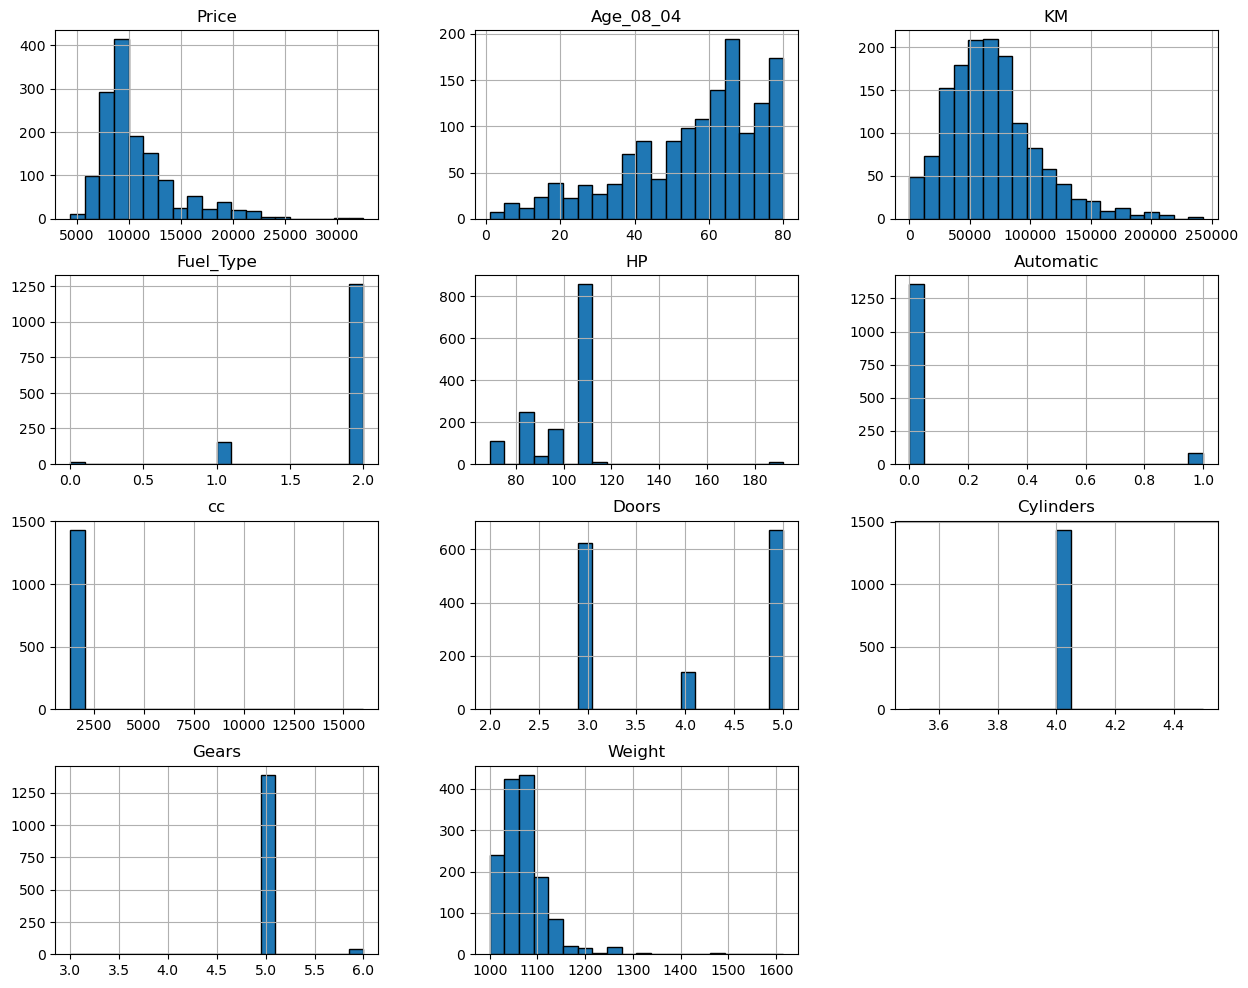

In [21]:
df.hist(bins=20 , edgecolor="Black", figsize=(15,12))
plt.show()

In [25]:
df['Fuel_Type'].value_counts()

Fuel_Type
2    1264
1     155
0      17
Name: count, dtype: int64

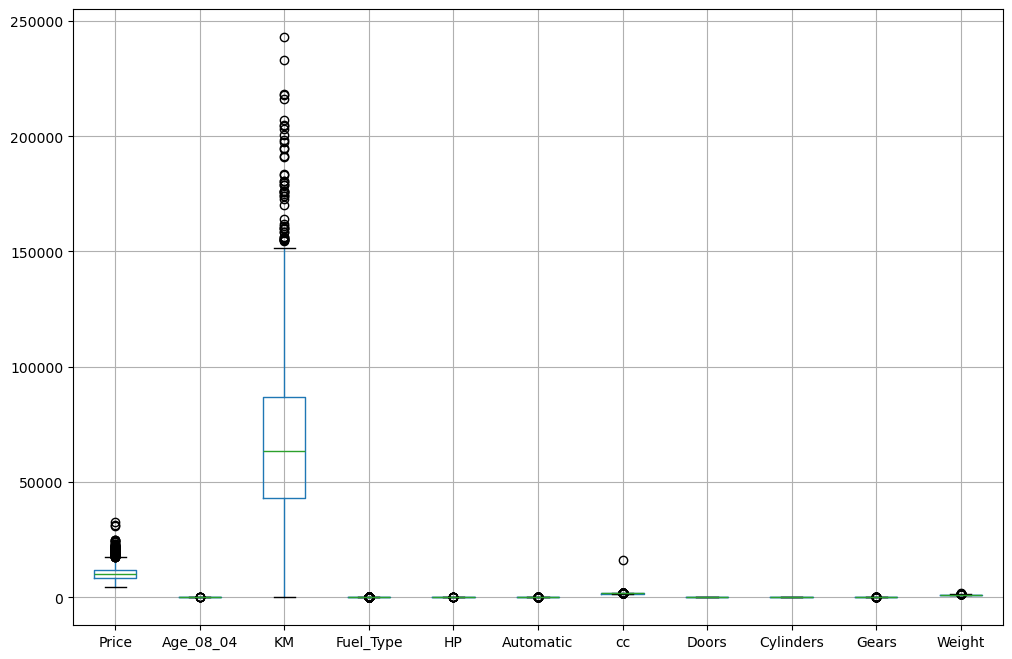

In [31]:
df.boxplot(figsize=(12,8))
plt.show()

In [39]:
outliers=['KM','Price','Age_08_04','HP','Automatic','cc','Gears','Weight']


for i in outliers:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[i] >= (Q1 - 1.5 * IQR)) & (df[i] <= (Q3 + 1.5 * IQR))]

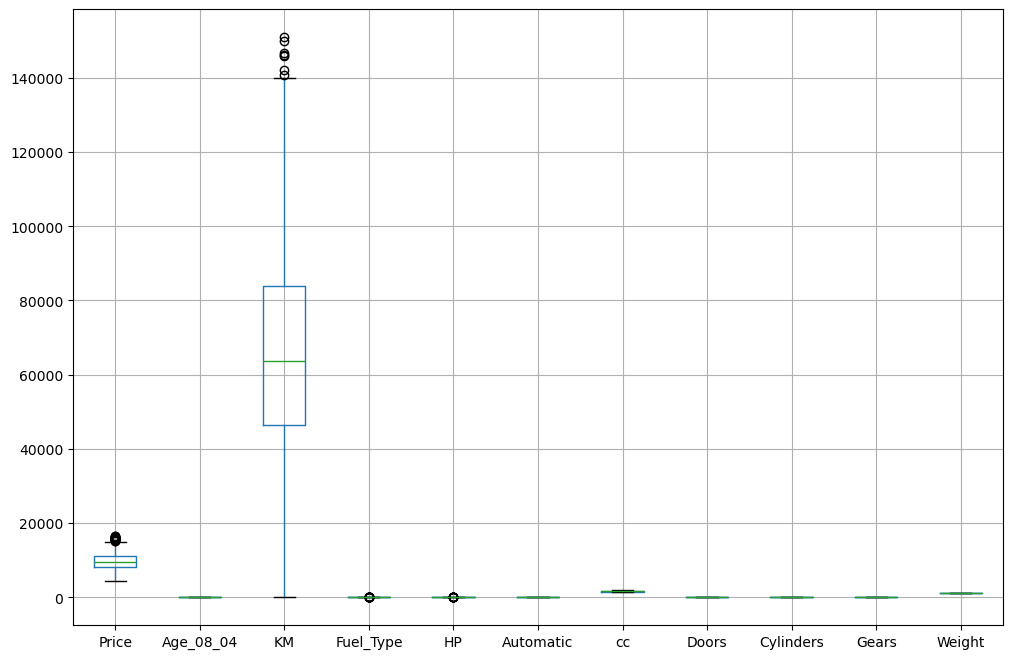

In [41]:
df.boxplot(figsize=(12,8))
plt.show()

In [43]:
df.describe()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1064.000000,1064.000000,1064.000000,1064.000000,1064.000000,1064.0,1064.000000,1064.000000,1064.0,1064.0,1064.000000
mean,9902.781955,59.482143,66333.981203,1.962406,102.834586,0.0,1515.723684,4.034774,4.0,5.0,1054.702068
std,2171.758285,14.750406,27344.724637,0.246321,10.522247,0.0,133.053525,0.952154,0.0,0.0,26.743029
min,4450.000000,19.000000,1.000000,0.000000,69.000000,0.0,1300.000000,2.000000,4.0,5.0,1000.000000
25%,8250.000000,50.000000,46321.250000,2.000000,97.000000,0.0,1400.000000,3.000000,4.0,5.0,1035.000000
50%,9500.000000,62.000000,63567.000000,2.000000,110.000000,0.0,1600.000000,4.000000,4.0,5.0,1050.000000
75%,10995.000000,71.000000,83864.500000,2.000000,110.000000,0.0,1600.000000,5.000000,4.0,5.0,1075.000000
max,16450.000000,80.000000,151000.000000,2.000000,116.000000,0.0,1900.000000,5.000000,4.0,5.0,1135.000000


In [77]:
z = df.drop(['Automatic', 'Gears','Cylinders'], axis=1)
z

,Price,Age_08_04,KM,Fuel_Type,HP,cc,Doors,Weight
9,12950,23,71138,1,69,1900,3,1105
20,15950,30,67660,2,110,1600,3,1105
22,15950,28,56349,2,110,1600,3,1120
24,16250,29,25813,2,110,1600,3,1120
25,15950,25,28450,2,110,1600,3,1120
...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,1300,3,1025
1432,10845,72,19000,2,86,1300,3,1015
1433,8500,71,17016,2,86,1300,3,1015
1434,7250,70,16916,2,86,1300,3,1015


In [79]:
correlation=z.corr(numeric_only=True)
correlation

,Price,Age_08_04,KM,Fuel_Type,HP,cc,Doors,Weight
Price,1.000000,-0.851575,-0.524738,-0.019694,0.131914,0.114169,0.173818,0.434083
Age_08_04,-0.851575,1.000000,0.459035,0.093026,-0.005510,-0.049935,-0.081975,-0.329058
KM,-0.524738,0.459035,1.000000,-0.211655,0.000661,0.107729,0.007237,-0.032986
Fuel_Type,-0.019694,0.093026,-0.211655,1.000000,0.104308,-0.211463,-0.006454,-0.266184
HP,0.131914,-0.005510,0.000661,0.104308,1.000000,0.754519,0.219730,0.462912
cc,0.114169,-0.049935,0.107729,-0.211463,0.754519,1.000000,0.201667,0.605651
Doors,0.173818,-0.081975,0.007237,-0.006454,0.219730,0.201667,1.000000,0.542345
Weight,0.434083,-0.329058,-0.032986,-0.266184,0.462912,0.605651,0.542345,1.000000


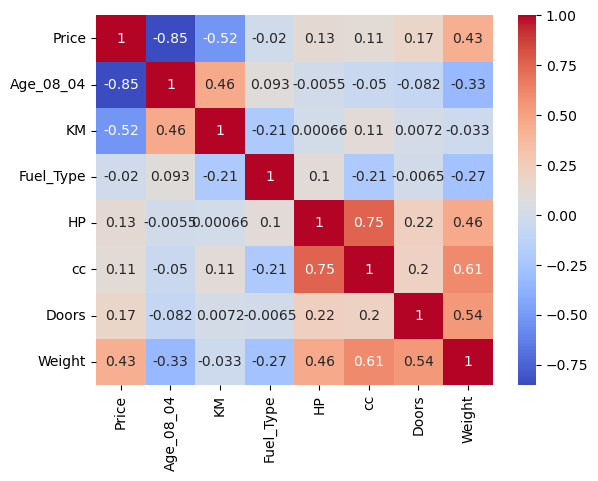

In [81]:
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.show()

In [83]:
x=df.drop(["Price","Cylinders"],axis=1)
x

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
9,23,71138,1,69,0,1900,3,5,1105
20,30,67660,2,110,0,1600,3,5,1105
22,28,56349,2,110,0,1600,3,5,1120
24,29,25813,2,110,0,1600,3,5,1120
25,25,28450,2,110,0,1600,3,5,1120
...,...,...,...,...,...,...,...,...,...
1431,69,20544,2,86,0,1300,3,5,1025
1432,72,19000,2,86,0,1300,3,5,1015
1433,71,17016,2,86,0,1300,3,5,1015
1434,70,16916,2,86,0,1300,3,5,1015


In [85]:
y=df["Price"]
y

9       12950
20      15950
22      15950
24      16250
25      15950
        ...  
1431     7500
1432    10845
1433     8500
1434     7250
1435     6950
Name: Price, Length: 1064, dtype: int64

In [87]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)
x

array([[-2.47446067,  0.17576618, -3.90896644, ..., -1.08728293,
         0.        ,  1.8816711 ],
       [-1.99967428,  0.04851548,  0.152694  , ..., -1.08728293,
         0.        ,  1.8816711 ],
       [-2.13532754, -0.36532373,  0.152694  , ..., -1.08728293,
         0.        ,  2.4428287 ],
       ...,
       [ 0.78121739, -1.80441288,  0.152694  , ..., -1.08728293,
         0.        , -1.48527444],
       [ 0.71339077, -1.80807161,  0.152694  , ..., -1.08728293,
         0.        , -1.48527444],
       [ 1.12035052, -2.42694617,  0.152694  , ...,  1.01420487,
         0.        ,  2.21836566]])

In [89]:
from sklearn.model_selection import train_test_split,GridSearchCV
x_train,x_test,y_train,y_test= train_test_split(x,y, test_size=0.2,random_state=42)

In [91]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [93]:
model1=LinearRegression()
model1.fit(x_test,y_test)

LinearRegression()

In [95]:
y_pred=model.predict(x_train)
y_pred

array([12589.22959285,  7248.54940446, 10464.27692775, 12213.7346269 ,
        8041.82261684, 10985.79593464, 11541.51032765, 10353.52182512,
        8176.69479337,  7886.91196946, 11371.91169603,  9182.03836281,
        8530.15170779,  7157.8778845 , 10068.9650302 ,  8029.13220476,
        8197.31814702, 13001.65255613,  8224.3468411 ,  8249.31623025,
        8063.61474225,  8190.65260123, 10164.24690571, 12081.46946746,
        7837.24681739,  8601.57207521, 11335.33722839, 10702.3321146 ,
       10535.68402851,  8942.30159267, 10223.05323626, 10327.06578367,
        9906.31014136,  9204.62403412,  8485.29940324,  8922.91017907,
       10379.7281789 ,  9250.37964233,  8499.36520764,  8503.72903535,
        8309.47994741,  7892.86711416, 13030.73596928,  8791.11397789,
       10906.68878359, 12768.05658221, 11668.03953712,  9144.46664293,
        9761.64827409,  9157.26318683, 10361.22529509,  8087.92978911,
       10419.61041179,  9500.70763176,  8781.93498094,  8101.29467158,
      

In [139]:
y_pred1=model1.predict(x_test)
y_pred1

array([15388.14658506,  8988.95961598,  7853.99602722,  8680.56057072,
        7396.01637682,  8660.92488538, 10055.54014407,  9220.95084929,
       12484.06043529,  8467.39714465, 12215.88113807,  7902.80155456,
        9488.56985077,  9505.83144812, 10856.05587433,  8779.33239384,
       10982.12529899,  7818.42841421, 10375.4948153 , 10227.42844044,
        7057.66355464, 11631.70914809,  9610.40791619,  8801.32669147,
        8245.26029213,  9147.01515152, 11409.39382099, 10682.54254699,
       10100.11098735,  9173.67352221,  7287.90529835, 12503.94907079,
        8755.19526333, 11584.23858846,  7865.54879714, 10549.69600678,
       10520.19032008,  9563.26053238, 11093.34627603, 12703.94475143,
        9446.25477857,  8554.71693768, 10484.10688203,  7649.45968039,
       10471.07268787, 12371.0801427 ,  8583.62971416, 12146.79345074,
        9259.078605  ,  7876.95935246, 11697.47511811,  7117.85019762,
       10497.19566339, 10526.10011337,  8983.50033878,  7190.21029415,
      

In [99]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred1)
score

0.7838384386966071

In [101]:
score1=r2_score(y_train, y_pred)
score1

0.7954461953003051

In [103]:
from sklearn.linear_model import Lasso, Ridge

In [105]:
lasso=Lasso(alpha=10)

In [107]:
lasso.fit(x_train, y_train)

Lasso(alpha=10)

In [109]:
lasso_pred=lasso.predict(x_test)
lasso_pred

array([15154.26176288,  8531.86089052,  7989.42550061,  7469.40005815,
        7147.65390303,  8635.6296605 ,  9756.5484266 ,  9205.15184031,
       12544.94353501,  8298.39639517, 12231.17075793,  7654.22917021,
        9177.24112621,  9297.41751138, 10825.28074051,  8729.26214693,
       10901.23253587,  7817.9951166 , 10060.03068863, 10177.12835051,
        7142.07150392, 11088.43782997,  9528.12729621,  8813.29660093,
        8256.90070953,  9248.29202687, 11132.16506927, 10713.99037508,
       10051.14679459,  9065.60935579,  7245.93718375, 12480.82331979,
        8474.26226355, 11552.9953374 ,  7645.80181414, 10404.01614173,
       10123.02834552,  9240.45930019, 10934.70585353, 12512.13522105,
        9594.88873722,  8448.80839422, 10550.59870014,  7785.93878251,
       10395.90017918, 12193.95448175,  8522.73944655, 12099.98940915,
        8898.29044868,  7526.98431506, 11763.2437057 ,  7086.24749545,
       10207.1457549 , 10229.9433369 ,  9329.48134787,  7092.19260847,
      

In [111]:
lasso_score=r2_score(y_test, lasso_pred)
lasso_score

0.761438508064384

In [113]:
lasso_pred1=lasso.predict(x_train)
lasso_pred1

array([12555.33461012,  7264.62052479, 10666.25090461, 12170.73845324,
        8057.02741888, 10986.92535961, 11527.1105902 , 10350.43701124,
        8188.87916376,  7914.62040679, 11354.18130078,  9162.94465102,
        8529.53072246,  7189.36334821, 10058.75278483,  8024.12528078,
        8198.38394832, 12964.26702065,  8223.8045054 ,  8261.60958817,
        8062.93777234,  8204.6164923 , 10161.50250843, 12318.03548472,
        7853.46081896,  8590.15229142, 11359.33520037, 10690.24897395,
       10548.50024669,  8954.50617952, 10229.55839516, 10333.77338566,
        9914.83198192,  9213.72238474,  8498.1129608 ,  8917.40073506,
       10376.47651095,  9277.20438443,  8492.66136806,  8530.96897608,
        8335.80567597,  7906.42625408, 13012.04253714,  8802.84511882,
       10881.8024436 , 12751.03561179, 11635.25394722,  9155.24503739,
        9756.07380648,  9152.56236424, 10368.58008969,  8117.95611657,
       10659.83990114,  9491.95173274,  8808.70062923,  8101.96814259,
      

In [115]:
lasso_score1=r2_score(y_train, lasso_pred1)
lasso_score1

0.7951805739539319

In [117]:
lasso.intercept_

9891.29107634928

In [119]:
lasso.coef_

array([-1540.48571633,  -355.85413198,   100.46748959,    99.72648919,
           0.        ,  -113.52321392,    24.40424793,     0.        ,
         451.60373575])

In [121]:
# Hyperparameter tuning
params={'alpha':[10,20,30,40,50]}

In [123]:
grid_search=GridSearchCV(lasso,params)

In [127]:
#Ridge technique
ridge=Ridge(alpha=10)

In [129]:
grid_search.fit(x_train,y_train)

GridSearchCV(estimator=Lasso(alpha=10),
             param_grid={'alpha': [10, 20, 30, 40, 50]})

In [131]:
grid_search.best_params_

{'alpha': 10}

In [133]:
ridge.fit(x_train,y_train)

Ridge(alpha=10)

In [135]:
ridge_pred=ridge.predict(x_test)
ridge_pred

array([15193.88389436,  8547.06047574,  7960.52885086,  7490.2726932 ,
        7146.70320382,  8628.28308626,  9745.94453441,  9193.29460426,
       12535.74294027,  8282.76693699, 12229.17597494,  7678.85599398,
        9243.17033418,  9278.96057942, 10838.53991227,  8754.3446546 ,
       10916.95363804,  7842.71223464, 10049.54165901, 10195.06735331,
        7129.33718349, 11128.37764165,  9515.50819726,  8793.92139502,
        8277.58546691,  9254.04759825, 11109.33029379, 10720.63632518,
       10069.68164599,  9065.37652709,  7248.83697948, 12497.02306195,
        8470.67452885, 11561.96488751,  7638.53035439, 10368.66913496,
       10121.71862678,  9235.72116744, 10963.74013236, 12469.59832157,
        9581.25060669,  8483.56924701, 10513.00189648,  7796.30717438,
       10413.96901529, 12223.52606024,  8551.79359121, 12106.04025315,
        8900.03798441,  7535.6536863 , 11718.49213954,  7088.88827922,
       10192.80601221, 10216.18175598,  9333.23553491,  7102.56581282,
      

In [137]:
ridge_score=r2_score(y_test, ridge_pred)
ridge_score

0.7636738181063341